<a href="https://colab.research.google.com/github/kulka193/SpaceInvaders/blob/master/actor_critic_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#env = gym.make("ALE/Breakout-v0")

### Notebook Overview: A2C Reinforcement Learning for Space Invaders

This notebook implements an **Advantage Actor-Critic (A2C)** reinforcement learning agent designed to play the Atari game **Space Invaders**.

**High-Level Gist:**
1.  **Environment Setup**: Installs necessary dependencies (Gym, Atari ROMs, virtual display tools) and initializes the `SpaceInvaders-v4` environment.
2.  **Model Architecture**: Defines a dual-headed Deep Learning model using TensorFlow/Keras:
    *   **Actor**: Responsible for choosing actions based on the current state (policy).
    *   **Critic**: Evaluates the state and provides a baseline for calculating the 'Advantage'.
3.  **Agent Logic**: Implements the `Agent` and `EnvWrapper` classes to handle frame preprocessing (grayscale, resizing, and stacking), experience replay, and reward discounting.
4.  **Training Loop**: Runs a series of episodes where the agent interacts with the environment, records video performance, and saves model checkpoints to Google Drive.
5.  **Visualization**: Includes helper functions to render and display MP4 videos of the agent's gameplay directly within the notebook.

In [ ]:
!pip install --upgrade git+https://github.com/openai/gym
!pip install autorom

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/openai/gym to /tmp/pip-req-build-5wb40zuv
  Running command git clone --filter=blob:none --quiet https://github.com/openai/gym /tmp/pip-req-build-5wb40zuv
  Resolved https://github.com/openai/gym to commit dcd185843a62953e27c2d54dc8c2d647d604b635
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install --upgrade gym[atari]

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.9/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
maze_craze.bin
pitfall.bin
ice_hockey.bin
carnival.bin
donkey_kong.bin
robotank.bin
defender.bin
battle_zone.bin
breakout.bin
berzerk.bin
lost_luggage.bin
montezuma_revenge.bin
space_war.bin
video_checkers.bin
flag_capture.bin
qbert.bin
pitfall2.bin
riverraid.bin
tic_tac_toe_3d.bin
galaxian.bin
word_zapper.bin
earthworld.bin
demon_attack.bin
seaquest.bin
solaris.bin
backgammon.bin
hangman.bin
phoenix.bin
frogger.bin
kaboom.bin
turmoil.bin
mr_do.bin
pooyan.bin
miniature_golf.bin
ms_pacman.bin
koolaid.bin
up_n_down.bin
venture.bin
tennis.bin
__pycache__
tetris.bin
asterix.bin
basic_math.bin
bowling.bin
atlantis2.bin
enduro.bin
klax.bin
tutankham.bin
chopper_command.bin
adventure.bin
video_cube.bin
frostbite.bin
krull.bin
space_invaders.bin
wizard_of_wor.bin
warlords.bin
__init__.py
crossbow.bin
double_dunk.bin
boxing.bin
elevator_a

In [ ]:
import gym
import ale_py
import random
import time

In [ ]:
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.9/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
maze_craze.bin
pitfall.bin
ice_hockey.bin
carnival.bin
donkey_kong.bin
robotank.bin
defender.bin
battle_zone.bin
breakout.bin
berzerk.bin
lost_luggage.bin
montezuma_revenge.bin
space_war.bin
video_checkers.bin
flag_capture.bin
qbert.bin
pitfall2.bin
riverraid.bin
tic_tac_toe_3d.bin
galaxian.bin
word_zapper.bin
earthworld.bin
demon_attack.bin
seaquest.bin
solaris.bin
backgammon.bin
hangman.bin
phoenix.bin
frogger.bin
kaboom.bin
turmoil.bin
mr_do.bin
pooyan.bin
miniature_golf.bin
ms_pacman.bin
koolaid.bin
up_n_down.bin
venture.bin
tennis.bin
__pycache__
tetris.bin
asterix.bin
basic_math.bin
bowling.bin
atlantis2.bin
enduro.bin
klax.bin
tutankham.bin
chopper_command.bin
adventure.bin
video_cube.bin
frostbite.bin
krull.bin
space_invaders.bin
wizard_of_wor.bin
warlords.bin
__init__.py
crossbow.bin
double_dunk.bin
boxing.bin
elevator_a

In [ ]:
env = gym.make('SpaceInvaders-v4',render_mode='rgb_array')

In [ ]:
!apt-get install x11-utils > /dev/null 2>&1
!pip install pyglet > /dev/null 2>&1
!apt-get install -y xvfb python-opengl > /dev/null 2>&1
!pip install pyvirtualdisplay > /dev/null 2>&1

In [ ]:
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
import matplotlib.pyplot as plt
%matplotlib inline
from gym.wrappers import RecordVideo, monitoring
from base64 import b64encode

In [ ]:
display = Display(visible=0, size=(400, 300))
display.start()

KeyboardInterrupt: ignored

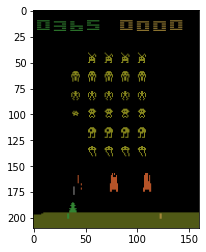

In [ ]:
env.reset()
img = plt.imshow(env.render())
for _ in range(1000):
    # just update the data
    img.set_data(env.render()) # just update the data
    ipythondisplay.display(plt.gcf())
    ipythondisplay.clear_output(wait=True)
    action = env.action_space.sample()
    _ = env.step(action)
env.reset()

In [ ]:
env.reset()
video_recorder = monitoring.video_recorder.VideoRecorder(env, 'video.mp4', enabled=True)

for _ in range(500):
    # just update the data
    env.render() # just update the data
    action = env.action_space.sample()
    video_recorder.capture_frame()
    _ = env.step(action)
env.reset()
video_recorder.close()
env.close()

/usr/local/lib/python3.9/dist-packages/gym/utils/passive_env_checker.py:289: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


[MoviePy] >>>> Building video video.mp4
[MoviePy] Writing video video.mp4


100%|██████████| 500/500 [00:00<00:00, 783.38it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: video.mp4 



In [ ]:
def render_mp4(videopath: str) -> str:
  """
  Gets a string containing a b4-encoded version of the MP4 video
  at the specified path.
  """
  mp4 = open(videopath, 'rb').read()
  base64_encoded_mp4 = b64encode(mp4).decode()
  return f'<video width=400 controls><source src="data:video/mp4;' \
         f'base64,{base64_encoded_mp4}" type="video/mp4"></video>'

In [ ]:
html = render_mp4('video.mp4')
ipythondisplay.HTML(html)

### Section 2: Model Architecture and Agent Logic

This section defines the core 'brain' of the reinforcement learning system. It moves from environment setup to the specific implementation of the neural networks and the decision-making agent.

**High-Level Gist:**
1.  **Neural Network Definition**: Uses TensorFlow to build two separate models:
    *   **The Actor**: Maps game states to a probability distribution over actions (the policy).
    *   **The Critic**: Estimates the expected future rewards from the current state (the value function).
2.  **Custom Loss Functions**: Implements specialized loss calculations, including Advantage-based gradients for the Actor and Huber loss for the Critic to ensure stable training.
3.  **The Agent Class**: Orchestrates the interaction loop, managing the 'memory' (experience replay) and the balancing of exploration vs. exploitation.
4.  **Reward Discounting**: Logic to calculate the long-term value of actions by applying a decay factor (gamma) to future rewards.

# Actor critic model

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPool2D, Input, Flatten
from tensorflow.keras.losses import mse, mae
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.models import Model
import os

In [ ]:
def actor_loss_function(advantages):
    def weighted_entropy_loss(y_true, y_pred):
        if K.dtype(y_true) != 'float64':
            y_true = K.cast(y_true, 'float64')
        if K.dtype(y_pred) != 'float64':
            y_pred = K.cast(y_pred, 'float64')
        cross_entropy = K.log(K.sum(-y_true * y_pred, axis=1) + 1e-6)
        return K.sum(cross_entropy * K.stop_gradient(K.cast(advantages, 'float64')))
    return weighted_entropy_loss

In [ ]:
class CustomModel(object):
    def __init__(self, input_shape, output_shape, optimizer, alpha=0.001):
        self.c_optimizer = optimizer(alpha)
        self.a_optimizer = optimizer(alpha)
        self.input_shape = input_shape
        self.output_shape = output_shape
        self._call_layers()
        self.c_loss_metric = tf.keras.metrics.Mean()
        self.a_loss_metric = tf.keras.metrics.Mean()
        tf.compat.v1.random.set_random_seed(12345)
        self.huber_loss = tf.keras.losses.Huber(reduction=tf.keras.losses.Reduction.SUM)


    def _call_layers(self):
        """
        """
        x = Input(shape=self.input_shape)
        h1 = Conv2D(32, (3, 3), strides=2, activation='relu', data_format='channels_last', padding='same')(x)
        h2 = Conv2D(64, (3, 3), strides=2, activation='relu', data_format='channels_last', padding='same')(h1)
        h2 = Conv2D(128, (3, 3), strides=2, activation='relu', data_format='channels_last', padding='same')(h1)
        f = Flatten()(h2)
        d1 = Dense(256, activation='relu')(f)
        pi = Dense(self.output_shape, activation='softmax')(d1)
        val = Dense(1, activation='linear')(d1)
        self.actor = Model(inputs=x, outputs=pi)
        self.critic = Model(inputs=x, outputs=val)
        print("Actor Model \n", self.actor.summary())
        print("Critic Model\n ", self.critic.summary())

    @tf.function
    def train_actor(self, data, advantages):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred = self.actor(x, training=True)
            loss_val = actor_loss_function(advantages=advantages)(y, y_pred)
        trainable_vars = self.actor.trainable_weights
        grads = tape.gradient(loss_val, trainable_vars)
        _ = self.a_optimizer.apply_gradients(zip(grads, trainable_vars))
        self.a_loss_metric.update_state(y, y_pred)
        #print(self.a_loss_metric.result())
        self.a_loss_metric.reset_states()
        return loss_val

    @tf.function
    def train_critic(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred = self.critic(x, training=True)
            loss_val = self.huber_loss(y, y_pred) #mse(y, y_pred)
        trainable_vars = self.critic.trainable_weights
        grads = tape.gradient(loss_val, trainable_vars)
        _ = self.c_optimizer.apply_gradients(zip(grads, trainable_vars))
        self.c_loss_metric.update_state(y, y_pred)
        #print(self.c_loss_metric.result())
        self.c_loss_metric.reset_states()
        return loss_val

    def save_model(self, folder_name, ckpt):
      self.actor.save(os.path.join(folder_name, 'a2c_model_'+ckpt+'.h5'))

### Section 3: The Reinforcement Learning Agent

This section defines the `Agent` class, which manages the lifecycle of training and decision-making for the model.

**High-Level Gist:**
1.  **Experience Management**: Uses a circular buffer (deque) to store states, actions, and rewards, allowing the agent to learn from past interactions.
2.  **Action Selection**: Implements a stochastic policy where actions are sampled from the Actor's probability distribution to encourage exploration.
3.  **Experience Replay**: Periodically updates the neural networks by calculating discounted rewards and optimizing the models based on the 'Advantage' (the difference between actual rewards and the Critic's predictions).
4.  **Reward Processing**: Includes logic to 'discount' future rewards, ensuring that the agent prioritizes immediate success while still considering long-term gains.

# Actor Critic Agent

In [ ]:
import numpy as np
from collections import Container, Counter, Iterator, deque
from tensorflow.keras.optimizers import Adam, RMSprop

<ipython-input-13-e6dd39aa8ffe>:2: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.10 it will stop working
  from collections import Container, Counter, Iterator, deque


In [ ]:
class Agent(object):
    def __init__(self, max_length, state_space=(84, 84, 4), action_space=6):
        self.max_length = max_length
        self.state_space = state_space
        self.action_space = action_space
        self.gamma = 0.99
        self.states = deque(maxlen=max_length)
        self.actions = deque(maxlen=max_length)
        self.rewards = deque(maxlen=max_length)
        self.memory_counter = 0
        self.actor_critic = CustomModel(optimizer=Adam, alpha=1e-3, input_shape=self.state_space,
                                  output_shape=self.action_space)
        self.actor_critic._call_layers()
        self.img_counter = 0

    def _clearExperiences(self, *args):
        for arg in args:
            if isinstance(arg, deque):
                arg.clear()

    def remember(self, state, action, reward, done):
        if len(state.shape) > 3:
            state = state.reshape(self.state_space)
        self.states.append(state)
        one_hot_encoded_actions = np.zeros((self.action_space,))
        one_hot_encoded_actions[action] = 1
        self.actions.append(one_hot_encoded_actions)
        self.rewards.append(reward)
        self.memory_counter += 1

    def act(self, states):
        pred_actions = np.array(self.actor_critic.actor(states)[0])   #self.actor.model(states)[0]
        normalized_pred_actions = pred_actions / pred_actions.sum()
        action = np.random.choice(self.action_space, 1, p=normalized_pred_actions)
        return action

    def replay(self):
        discounted_rewards = np.array(self.discount_rewards(self.rewards))
        #self.actions = np.array(self.actions)
        #self.states = np.array(self.states)
        value_fn = self.actor_critic.critic(np.array(self.states))[0]
        self.advantages = discounted_rewards - value_fn
        actor_loss = self.actor_critic.train_actor((np.array(self.states), np.array(self.actions)), advantages=self.advantages)
        critic_loss = self.actor_critic.train_critic((np.array(self.states), value_fn))
        if self.memory_counter % 1000:
            print('states 0? : \n ', np.all(np.array(self.states)==0.))
            print('losses after seeing', self.memory_counter, ' frames is actor: ', actor_loss, '\t critic: ', critic_loss)
        if self.memory_counter % 50000 == 0:
            self._clearExperiences(self.states, self.actions, self.rewards)


    def discount_rewards(self, rewards):
        dr = []
        cumulative_rewards = 0
        for rw in list(rewards)[::-1]:
            cumulative_rewards = cumulative_rewards * self.gamma + rw
            dr.append(cumulative_rewards)
        dr = np.asarray(dr, dtype='float32')
        #normalized_dr = (dr - np.mean(dr)) / np.std(dr)
        return dr.tolist()

# More imports

In [ ]:
import glob
import io
import base64

In [ ]:
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools 2>&1
!pip install ez_setup > /dev/null 2>&1
#!pip install gym[atari] > /dev/null 2>&1

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/



### Attention: Change the below code snippet as it mounts G-drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Actor Critic Environment

In [ ]:

model_out_dir = './drive/MyDrive/RL_modified_runs/A2C'

if not os.path.exists(model_out_dir):
    os.mkdir(model_out_dir)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage.color import rgb2gray

In [ ]:
class EnvWrapper:
    def __init__(self, game='SpaceInvaders-v4', skip_frames=4, frame_width=84, frame_height=84):
        self.skip_frames = skip_frames
        # self.num_frames = num_frames
        self.env = gym.make(game, render_mode='rgb_array')
        self.frame_width = frame_width
        self.frame_height = frame_height
        self.input_feature_shape = (self.frame_width, self.frame_height)
        self.state = None
        self.action_space = [i for i in range(self.env.action_space.n)]
        self.agent = Agent(max_length=10000, state_space=(self.frame_width, self.frame_height) + (self.skip_frames,), action_space=6)

    def preprocess(self, img, start=False):
        #grayscale = img.astype(np.float32).mean(axis=2)
        grayscale = np.uint8(resize(rgb2gray(img[0]), self.input_feature_shape, mode='constant'))
        reshaped_grayscale = grayscale.reshape(1, self.frame_width, self.frame_height, 1)
        print('because grayscale all 0s? ', np.all(img[0]==0.))
        if start or self.state is None:
            self.state = np.repeat(reshaped_grayscale, self.skip_frames, axis=3)
        else:
            self.state = np.append(reshaped_grayscale, self.state[:, :, :, :self.skip_frames - 1], axis=3)

    def reset(self):
        self.preprocess(self.env.reset(), start=True)
        return self.get_next_state()

    def get_next_state(self):
        return self.state

    def render(self):
        self.env.render()

    '''
    def render(self, num_steps):
        img = plt.imshow(self.env.render('rgb_array'))
        for _ in range(num_steps):
            img.set_data(self.env.render('rgb_array'))  # just update the data
            action = self.env.action_space.sample()
            self.env.step(action)
    '''

    def step(self, action_idx):
        action = self.action_space[action_idx[0]]
        prev_s = None
        total_rewards = 0
        done, info = None, None
        for _ in range(0, self.skip_frames):
            s, r, done, _, info = self.env.step(action)
            print(s.shape)
            if np.all(s==0.):
              print("===================oops==================",s)
            total_rewards += r
            if done:
                print('done: ')
                break
            prev_s = s
        if prev_s is not None:
            s = np.maximum.reduce([s, prev_s])
        self.preprocess(s)
        return total_rewards, done, info


### Main function to run the agent

In [ ]:
def main():
    env1 = EnvWrapper()
    state = env1.reset()
    num_episodes = 10000
    time_steps, done = 0, False
    episodic_reward = []
    video_recorder = monitoring.video_recorder.VideoRecorder(env1.env, os.path.join(model_out_dir, 'video.mp4'), enabled=True)
    for e in range(num_episodes):
        accum_rewards = 0
        while not done:
            action = env1.agent.act(state)  #agent.act(state)
            reward, done, info = env1.step(action)
            accum_rewards += reward
            episodic_reward.append(accum_rewards)
            state = env1.get_next_state()
            if done:
                if e % 100 == 0:
                    env1.render()
                    print('avg reward @ epoch no. %d : %0.2f' % (e+1, sum(episodic_reward)/len(episodic_reward)))
                    video_recorder.capture_frame()
                    env1.agent.actor_critic.save_model(folder_name=model_out_dir,ckpt=str(e+1))
                break
            env1.agent.remember(state, action, reward, done)
        env1.agent.replay()
        state = env1.reset()
    video_recorder.close()
    env.close()
    html = render_mp4(os.path.join(model_out_dir,'video.mp4'))
    ipythondisplay.HTML(html)

In [ ]:
main()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 84, 84, 4)]       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 42, 42, 32)        1184      
                                                                 
 conv2d_8 (Conv2D)           (None, 21, 21, 128)       36992     
                                                                 
 flatten_2 (Flatten)         (None, 56448)             0         
                                                                 
 dense_6 (Dense)             (None, 256)               14450944  
                                                                 
 dense_7 (Dense)             (None, 6)                 1542      
                                                                 
Total params: 14,490,662
Trainable params: 14,490,662
Non-t

/usr/local/lib/python3.9/dist-packages/gym/utils/passive_env_checker.py:289: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


(210, 160, 3)
(210, 160, 3)
(210, 160, 3)
(210, 160, 3)
because grayscale all 0s?  True
(210, 160, 3)
(210, 160, 3)
(210, 160, 3)
(210, 160, 3)
because grayscale all 0s?  True
(210, 160, 3)
done: 
because grayscale all 0s?  True
avg reward @ epoch no. 1 : 24.41
states 0? : 
  True
losses after seeing 126  frames is actor:  tf.Tensor(nan, shape=(), dtype=float64) 	 critic:  tf.Tensor(0.0, shape=(), dtype=float32)
because grayscale all 0s?  False
states 0? : 
  True
losses after seeing 126  frames is actor:  tf.Tensor(nan, shape=(), dtype=float64) 	 critic:  tf.Tensor(0.0, shape=(), dtype=float32)
because grayscale all 0s?  False
states 0? : 
  True
losses after seeing 126  frames is actor:  tf.Tensor(nan, shape=(), dtype=float64) 	 critic:  tf.Tensor(0.0, shape=(), dtype=float32)
because grayscale all 0s?  False
states 0? : 
  True
losses after seeing 126  frames is actor:  tf.Tensor(nan, shape=(), dtype=float64) 	 critic:  tf.Tensor(0.0, shape=(), dtype=float32)
because grayscale all 0

KeyboardInterrupt: ignored